# Tehran Houses Price Prediction
This notebook aims to build a predictive model for housing prices in Tehran. By analyzing a dataset containing various features of properties, including location, size, age, and amenities, we will explore the factors influencing house prices and develop a model to estimate the price of a house based on its characteristics. This project involves data loading, cleaning, exploratory data analysis, potentially feature engineering, model selection, training, and evaluation to provide insights into the Tehran real estate market and a tool for price estimation.


## Importing library

In [82]:
# Just for first time
!pip install category_encoders
!pip install xgboost

In [83]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.float_format', '{:.2f}'.format)

## Data Loading

In [84]:
for dirname, _, filenames in os.walk('/content'):
  for filename in filenames:
    file_name = os.path.join(dirname, filename)
    print(file_name)
    break
  break

/content/divar_tehran_houses.csv


In [85]:
try:
    housing = pd.read_csv(file_name)
except FileNotFoundError:
    print("Please upload the 'divar_tehran_houses.csv' file.")
    data = {'title': ['آگهی 1'], 'location': ['تهران، پونک'], 'time_posted': ['2023-01-01'], 'scraped_time': ['2023-01-02'], 'meterage': [100], 'build_year': [1390], 'rooms': [2], 'floor': [3], 'has_parking': [True], 'has_warehouse': [True], 'has_balcony': [True], 'has_elevator': [True], 'is_renovated': [False], 'price_per_meter': [100000000], 'price': [10000000000], 'link': ['http://example.com']}
    housing = pd.DataFrame(data)
housing.head()

,title,location,time_posted,scraped_time,meterage,build_year,rooms,floor,has_parking,has_warehouse,has_balcony,has_elevator,is_renovated,price_per_meter,price,link
0,فروش آپارتمان ۱۲۵ متری ۳ خوابه در حکیمیه,تهران، حکیمیه، خ لاله ها,۱ ساعت پیش,6/24/2025 15:29,125,1375.00,3.00,2.00,True,True,True,True,True,80800000.00,10100000000.00,https://divar.ir/v/%D9%81%D8%B1%D9%88%D8%B4-%D...
1,125 متر، 3 خواب، بازسازی شده,تهران، حکیمیه، خ لاله ها,۲ هفته پیش,6/24/2025 15:29,125,1375.00,3.00,2.00,True,True,True,True,True,80800000.00,10100000000.00,https://divar.ir/v/125-%D9%85%D8%AA%D8%B1-3-%D...
2,۱۱۶ متری ۲ خوابه سالن پرده خور (۲پارکینگ سندی),تهران، سازمان آب، بلوار جوانمردان,دقایقی پیش,6/24/2025 15:29,116,1399.00,2.00,5.00,True,True,True,True,True,108620000.00,12600000000.00,https://divar.ir/v/%DB%B1%DB%B1%DB%B6-%D9%85%D...
3,۸۳متر/به ریال خریدکن به دلار سودکن/تهاتر/صدرا,تهران، شهرک صدرا,دقایقی پیش,6/24/2025 15:29,83,1404.00,2.00,10.00,True,True,False,True,False,25000000.00,2075000000.00,https://divar.ir/v/%DB%B8%DB%B3%D9%85%D8%AA%D8...
4,تک واحدی تخلیه فول بازسازی,تهران، جوادیه، خ دارابی,دقایقی پیش,6/24/2025 15:29,54,1382.00,1.00,2.00,False,True,False,False,True,36111000.00,1950000000.00,https://divar.ir/v/%D8%AA%DA%A9-%D9%88%D8%A7%D...


In [86]:
df = housing.copy()

## Data Analysis and EDA

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            3941 non-null   object 
 1   location         3941 non-null   object 
 2   time_posted      3941 non-null   object 
 3   scraped_time     3941 non-null   object 
 4   meterage         3941 non-null   int64  
 5   build_year       3903 non-null   float64
 6   rooms            3925 non-null   float64
 7   floor            3810 non-null   float64
 8   has_parking      3941 non-null   bool   
 9   has_warehouse    3941 non-null   bool   
 10  has_balcony      3941 non-null   bool   
 11  has_elevator     3941 non-null   bool   
 12  is_renovated     3941 non-null   bool   
 13  price_per_meter  3941 non-null   float64
 14  price            3941 non-null   float64
 15  link             3941 non-null   object 
dtypes: bool(5), float64(5), int64(1), object(5)
memory usage: 35

In [88]:
df.columns

Index(['title', 'location', 'time_posted', 'scraped_time', 'meterage',
       'build_year', 'rooms', 'floor', 'has_parking', 'has_warehouse',
       'has_balcony', 'has_elevator', 'is_renovated', 'price_per_meter',
       'price', 'link'],
      dtype='object')

In [89]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 3941
Number of columns: 16


In [90]:
df.dtypes

,0
title,object
location,object
time_posted,object
scraped_time,object
meterage,int64
build_year,float64
rooms,float64
floor,float64
has_parking,bool
has_warehouse,bool


In [91]:
df.isnull().sum()

,0
title,0
location,0
time_posted,0
scraped_time,0
meterage,0
build_year,38
rooms,16
floor,131
has_parking,0
has_warehouse,0


In [92]:
print(f'Total number of NaN values in dataset is: {df.isna().sum().sum()}')

Total number of NaN values in dataset is: 185


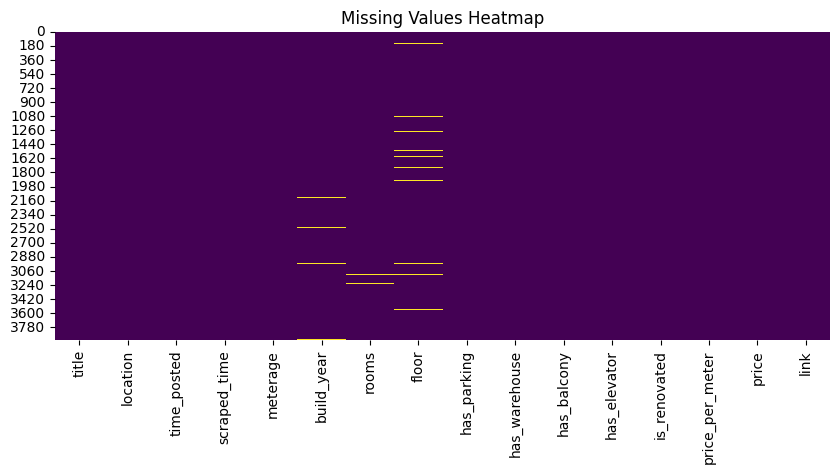

In [93]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [94]:
print(f'Number of duplicated rows: {df.duplicated().sum()}')

Number of duplicated rows: 0


In [95]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [96]:
corr_matrix = df.select_dtypes(include=['number']).corr()
corr_matrix

,meterage,build_year,rooms,floor,has_parking,has_warehouse,has_balcony,has_elevator,is_renovated,price_per_meter,price
meterage,1.00,0.17,0.62,0.16,0.23,0.11,0.05,0.20,-0.10,0.04,0.06
build_year,0.17,1.00,0.22,0.27,0.40,0.08,0.07,0.65,-0.35,0.02,0.03
rooms,0.62,0.22,1.00,0.19,0.34,0.14,0.12,0.28,-0.08,0.04,0.05
floor,0.16,0.27,0.19,1.00,0.15,0.08,0.11,0.21,-0.13,0.02,0.02
has_parking,0.23,0.40,0.34,0.15,1.00,0.20,0.10,0.41,-0.12,0.02,0.02
has_warehouse,0.11,0.08,0.14,0.08,0.20,1.00,0.09,0.11,0.04,0.01,0.01
has_balcony,0.05,0.07,0.12,0.11,0.10,0.09,1.00,0.08,0.31,0.02,0.03
has_elevator,0.20,0.65,0.28,0.21,0.41,0.11,0.08,1.00,-0.20,0.01,0.02
is_renovated,-0.10,-0.35,-0.08,-0.13,-0.12,0.04,0.31,-0.20,1.00,0.01,0.00
price_per_meter,0.04,0.02,0.04,0.02,0.02,0.01,0.02,0.01,0.01,1.00,0.93


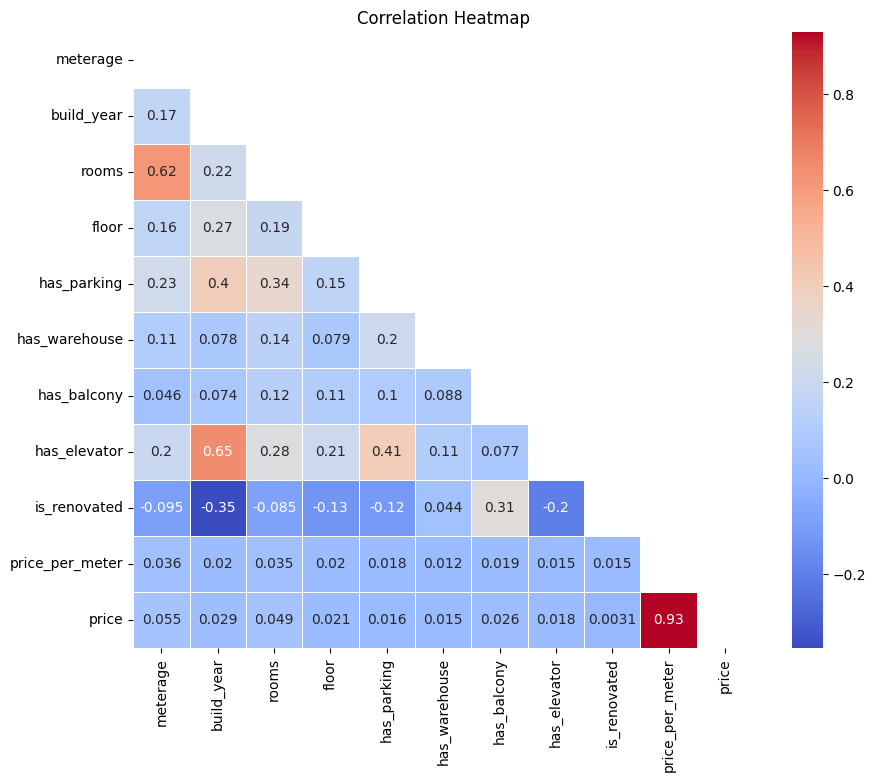

In [97]:
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix))
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [98]:
corr_with_price = corr_matrix['price'].sort_values(ascending=False)
corr_with_price

,price
price,1.00
price_per_meter,0.93
meterage,0.06
rooms,0.05
build_year,0.03
has_balcony,0.03
floor,0.02
has_elevator,0.02
has_parking,0.02
has_warehouse,0.01


In [99]:
df['location'].value_counts()

,count
location,
تهران، شهر‌زیبا,150
تهران، چیتگر,123
تهران، مبارک‌آباد بهشتی,110
تهران، شهر زیبا,105
تهران، دریاچه شهدای خلیج فارس,87
...,...
تهران، شهرک کیانشهر، خ روانبخش,1
تهران، جنت‌آباد جنوبی، خ وکیلی,1
تهران، دروازه شمیران، خ یکم,1


In [100]:
df.describe()

,meterage,build_year,rooms,floor,has_parking,has_warehouse,has_balcony,has_elevator,is_renovated,price_per_meter,price
count,3941.00,3903.00,3925.00,3810.00,3941.00,3941.00,3941.00,3941.00,3941.00,3941.00,3941.00
mean,91.16,1395.42,1.87,3.65,0.80,0.88,0.49,0.79,0.23,490386845.72,60422923071.78
std,62.39,7.96,0.70,3.36,0.40,0.33,0.50,0.41,0.42,7049658456.26,1093794895554.33
min,8.00,1371.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,111.00
25%,60.00,1389.00,1.00,2.00,1.00,1.00,0.00,1.00,0.00,41891000.00,2550000000.00
50%,78.00,1398.00,2.00,3.00,1.00,1.00,0.00,1.00,0.00,74193000.00,5300000000.00
75%,108.00,1403.00,2.00,4.00,1.00,1.00,1.00,1.00,0.00,119047000.00,11400000000.00
max,1611.00,1404.00,4.00,29.00,1.00,1.00,1.00,1.00,1.00,215000000000.00,48375000000000.00


In [101]:
df['price'].describe()

,price
count,3941.00
mean,60422923071.78
std,1093794895554.33
min,111.00
25%,2550000000.00
50%,5300000000.00
75%,11400000000.00
max,48375000000000.00


In [102]:
df['meterage'].describe()

,meterage
count,3941.00
mean,91.16
std,62.39
min,8.00
25%,60.00
50%,78.00
75%,108.00
max,1611.00


In [103]:
df['floor'].describe()

,floor
count,3810.00
mean,3.65
std,3.36
min,1.00
25%,2.00
50%,3.00
75%,4.00
max,29.00


In [104]:
df.sort_values('price').head(10)

,title,location,time_posted,scraped_time,meterage,build_year,rooms,floor,has_parking,has_warehouse,has_balcony,has_elevator,is_renovated,price_per_meter,price,link
139,95 متـر / بـهترین سـازه منطقه / بـرج بـاغ رومـ...,تهران، کوی فردوس,۱ ساعت پیش,6/24/2025 15:50,95,1404.00,2.00,2.00,1,1,1,1,0,0.00,111.00,https://divar.ir/v/95-%D9%85%D8%AA%D9%80%D8%B1...
157,برج باغ مدرن روماک / 106متر / پرداخت ایده آل,تهران، ارم,۱ ساعت پیش,6/24/2025 15:53,106,1404.00,2.00,4.00,1,1,1,1,0,0.00,111.00,https://divar.ir/v/%D8%A8%D8%B1%D8%AC-%D8%A8%D...
3837,فروش آپارتمان ۷۰ متری ۲ خوابه ورزی جنوبی,تهران، کوی فردوس,۱ ساعت پیش,6/27/2025 21:11,70,1389.00,2.00,4.00,1,1,1,1,1,0.00,1000.00,https://divar.ir/v/%D9%81%D8%B1%D9%88%D8%B4-%D...
1356,برج الماس دریاچه ۱۴۵.۹ متری طبقه ۹ دوخوابه فول,تهران، شهرک راه‌آهن,دقایقی پیش,6/26/2025 16:55,146,1403.00,2.00,9.00,1,1,1,1,0,0.00,1000.00,https://divar.ir/v/%D8%A8%D8%B1%D8%AC-%D8%A7%D...
1265,واحد دوخوابه ۹۱ متری علی آباد،بایندریان,تهران، علی‌آباد، خ عباس بایندریان,یک ربع پیش,6/26/2025 16:16,91,1398.00,2.00,4.00,1,0,1,1,0,0.00,1000.00,https://divar.ir/v/%D9%88%D8%A7%D8%AD%D8%AF-%D...
138,دفـتــر فــروش بــرج بــاغ مــدرن رومـاکـ,تهران، صادقیه,۱ ساعت پیش,6/24/2025 15:50,108,1404.00,2.00,4.00,1,1,1,1,0,0.00,1000.00,https://divar.ir/v/%D8%AF%D9%81%D9%80%D8%AA%D9...
2778,فروش آپارتمان ۸۰ متری ۲ خوابه در تهران‌سر,تهران، تهران‌سر,یک ربع پیش,6/27/2025 11:53,80,1404.00,2.00,6.00,1,1,1,1,0,0.00,1000.00,https://divar.ir/v/%D9%81%D8%B1%D9%88%D8%B4-%D...
2414,۹۵ متر تکواحدی (بازسازی شده) بعلت مهاجرت,تهران، گمرک,۱۲ ساعت پیش,6/27/2025 0:52,95,1380.00,2.00,1.00,0,0,0,0,0,0.00,1000.00,https://divar.ir/v/%DB%B9%DB%B5-%D9%85%D8%AA%D...
162,بـرج بـاغ مـدرن رومـاکــ /۱۱۷ مـتـر/ شرایط اید...,تهران، جنت‌آباد جنوبی,۱ ساعت پیش,6/24/2025 15:54,117,1404.00,2.00,4.00,1,1,0,1,0,0.00,1111.00,https://divar.ir/v/%D8%A8%D9%80%D8%B1%D8%AC-%D...
165,119 متـر / بـرج با مشاعات کامل رفـاهـی ( ROMAK ),تهران، پونک,۱ ساعت پیش,6/24/2025 15:54,119,1404.00,2.00,2.00,1,1,0,1,0,0.00,1111.00,https://divar.ir/v/119-%D9%85%D8%AA%D9%80%D8%B...


In [105]:
df.sort_values('price', ascending=False).head(10)

,title,location,time_posted,scraped_time,meterage,build_year,rooms,floor,has_parking,has_warehouse,has_balcony,has_elevator,is_renovated,price_per_meter,price,link
3448,فروش آپارتمان ۲۲۵ متری ۳ خوابه در سازمان برنامه,تهران، سازمان برنامه، میدان نسترن دوم,دقایقی پیش,6/27/2025 15:14,225,1404.00,3.00,4.00,1,1,1,1,0,215000000000.00,48375000000000.00,https://divar.ir/v/%D9%81%D8%B1%D9%88%D8%B4-%D...
1516,فروش آپارتمان ۱۷۰ متری ۳ خوابه در ستارخان,تهران، ستارخان، خ پردیس,۱ ساعت پیش,6/26/2025 17:33,170,1404.00,3.00,2.00,1,1,1,1,0,191176000000.00,32500000000000.00,https://divar.ir/v/%D9%81%D8%B1%D9%88%D8%B4-%D...
3692,آپارتمان، ۱۱۰ متری، ۲ خوابه عدل شمالی,تهران، پونک، خ باقرپور,۴ ساعت پیش,6/27/2025 20:22,110,1404.00,2.00,2.00,1,1,0,1,0,163636000000.00,18000000000000.00,https://divar.ir/v/%D8%A2%D9%BE%D8%A7%D8%B1%D8...
1826,۱۱۰متر لوکس و برند ۲پارکینگ تاپ لوکیشن فردوس,تهران، کوی فردوس، میدان گلستان شمالی,۴ ساعت پیش,6/26/2025 18:39,110,1404.00,2.00,3.00,1,1,1,1,1,130000000000.00,14300000000000.00,https://divar.ir/v/%DB%B1%DB%B1%DB%B0%D9%85%D8...
1901,فروش فوری ، ۱۴۳ متر، تهران شریف،همراه شهر,تهران، شریف,۴ ساعت پیش,6/26/2025 18:55,143,1398.00,3.00,14.00,1,1,1,1,0,96503496000.00,13800000000000.00,https://divar.ir/v/%D9%81%D8%B1%D9%88%D8%B4-%D...
197,فروش و تهاتر آپارتمان ۲۰۵ متری,تهران، سرو آزاد، بزرگراه خرازی,۲ ساعت پیش,6/24/2025 16:00,205,1396.00,3.00,11.00,0,1,1,1,1,65000000000.00,13325000000000.00,https://divar.ir/v/%D9%81%D8%B1%D9%88%D8%B4-%D...
1025,۱۰۸ متر/۲خواب/فول/روبه آفتاب/فایل شخصی,تهران، تهران‌نو,نیم ساعت پیش,6/25/2025 12:15,108,1393.00,2.00,5.00,1,1,0,1,0,103241000000.00,11150000000000.00,https://divar.ir/v/%DB%B1%DB%B0%DB%B8-%D9%85%D...
2129,واحد ۹۴ متری دوخواب جنوبی شهرک چیتگر برج G,تهران، سرو آزاد، بلوار پژوهش,۶ ساعت پیش,6/26/2025 19:40,94,1401.00,2.00,12.00,1,1,1,1,0,95212765000.00,8950000000000.00,https://divar.ir/v/%D9%88%D8%A7%D8%AD%D8%AF-%D...
2886,سالن اکواریوم نور / فول امکانات / ارزنده و به ...,تهران، استاد معین، خ کوچکی,نیم ساعت پیش,6/27/2025 12:18,93,1398.00,2.00,6.00,1,1,1,1,1,77419354000.00,7200000000000.00,https://divar.ir/v/%D8%B3%D8%A7%D9%84%D9%86-%D...
2845,فروش آپارتمان ۸۰ متری ۲ خوابه در دکتر هوشیار,تهران، دکتر هوشیار، خ محمدی مخبر,دقایقی پیش,6/27/2025 12:08,80,1402.00,2.00,2.00,1,1,1,1,1,89375000000.00,7150000000000.00,https://divar.ir/v/%D9%81%D8%B1%D9%88%D8%B4-%D...


In [106]:
def flag_price(price):
  if price < 8e8:
    return 'Too Low'
  elif price > 15e10:
    return 'Too High'
  else:
    return 'Normal'

In [107]:
df['price_flag'] = df['price'].apply(flag_price)

In [108]:
df['price_flag'].value_counts()

,count
price_flag,
Normal,3712
Too Low,208
Too High,21


In [109]:
df.groupby('price_flag')['price'].describe().T

price_flag,Normal,Too High,Too Low
count,3712.00,21.00,208.00
mean,9677440598.06,9624904761904.76,389809259.08
std,12740499769.50,11793620084201.29,226952303.53
min,800000000.00,160000000000.00,111.00
25%,2887500000.00,2100000000000.00,260000000.00
50%,5600000000.00,6900000000000.00,490000000.00
75%,11700000000.00,13325000000000.00,500000000.00
max,133000000000.00,48375000000000.00,760000000.00


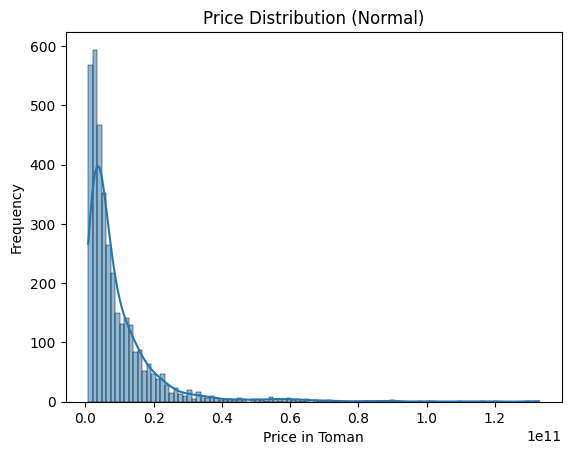

In [110]:
sns.histplot(df[df['price_flag'] == 'Normal']['price'], bins=100, kde=True)
plt.title("Price Distribution (Normal)")
plt.xlabel("Price in Toman")
plt.ylabel("Frequency")
plt.show()

In [111]:
def plot_hist_kde_box(column_name, data=df):
  plt.figure(figsize=(15, 5))

  # Plot Histogram
  plt.subplot(1, 3, 1)
  sns.histplot(data[column_name], kde=True, color='b')
  plt.title(f"{column_name.capitalize()} Distribution", fontsize=16, fontweight='bold', color='purple')
  plt.xlabel(column_name.capitalize(), fontsize=14)
  plt.ylabel("Frequency", fontsize=14)

  # Plot KDE
  plt.subplot(1, 3, 2)
  sns.kdeplot(data=data, x=column_name, fill=True, color='r')
  plt.title(f"Kernel Density Estimate of {column_name.capitalize()}", fontsize=16, fontweight='bold', color='purple')
  plt.xlabel(column_name.capitalize(), fontsize=14)
  plt.ylabel("Density", fontsize=14)
  plt.xlim(data[column_name].min(), data[column_name].max())

  # Plot Box Plot
  plt.subplot(1, 3, 3)
  sns.boxplot(y=data[column_name], color='g')
  plt.title(f"Box Plot of {column_name.capitalize()}", fontsize=16, fontweight='bold', color='purple')
  plt.xlabel(column_name.capitalize(), fontsize=14)

  plt.tight_layout()
  plt.show()

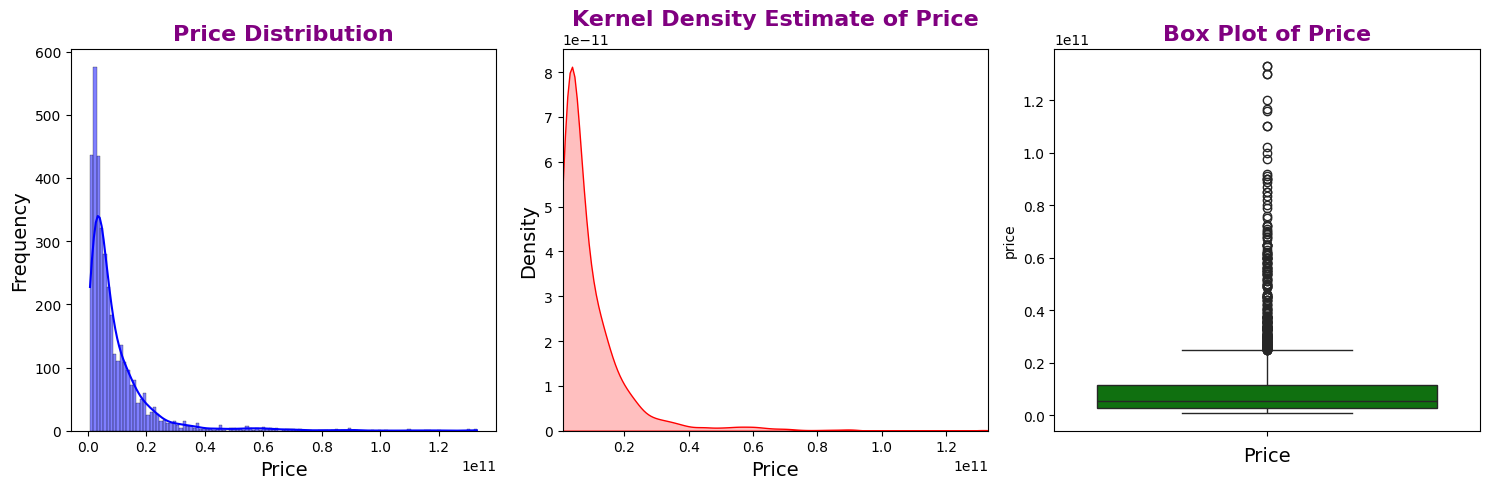

In [112]:
plot_hist_kde_box('price', data=df[(df['price'] > 8e8) & (df['price'] < 15e10)])

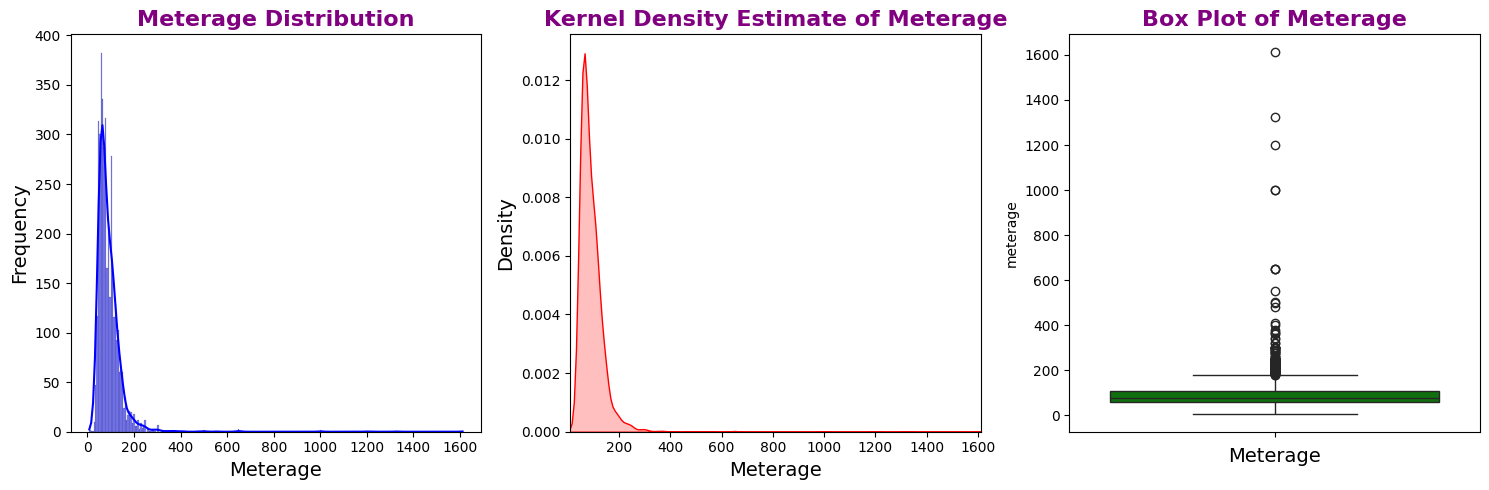

In [113]:
plot_hist_kde_box('meterage')

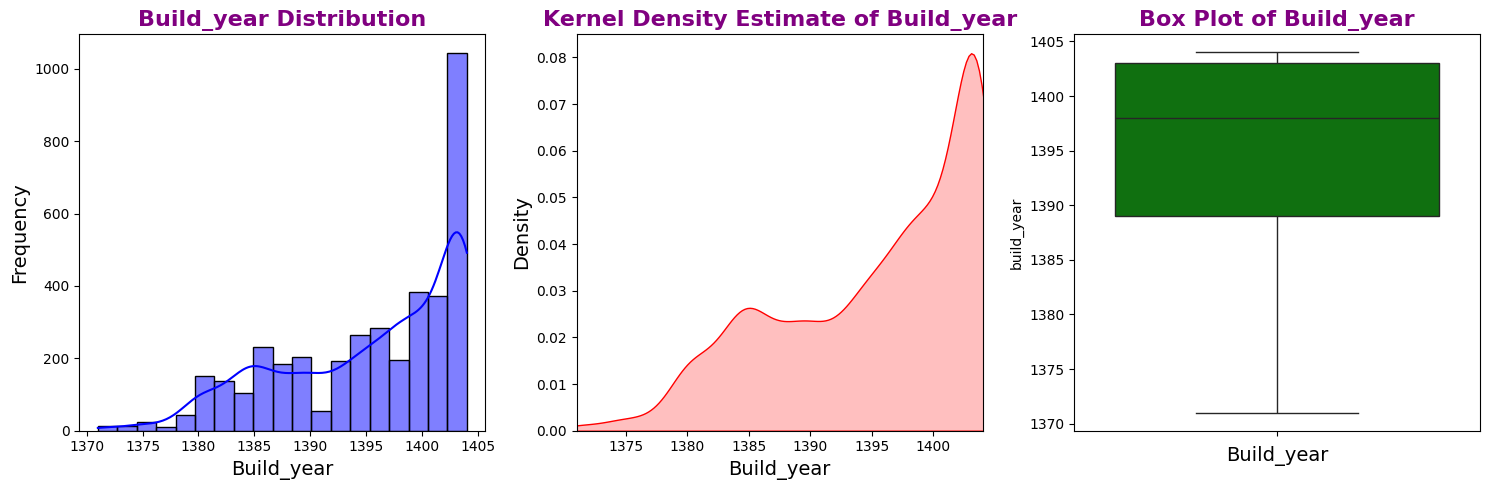

In [114]:
plot_hist_kde_box('build_year')

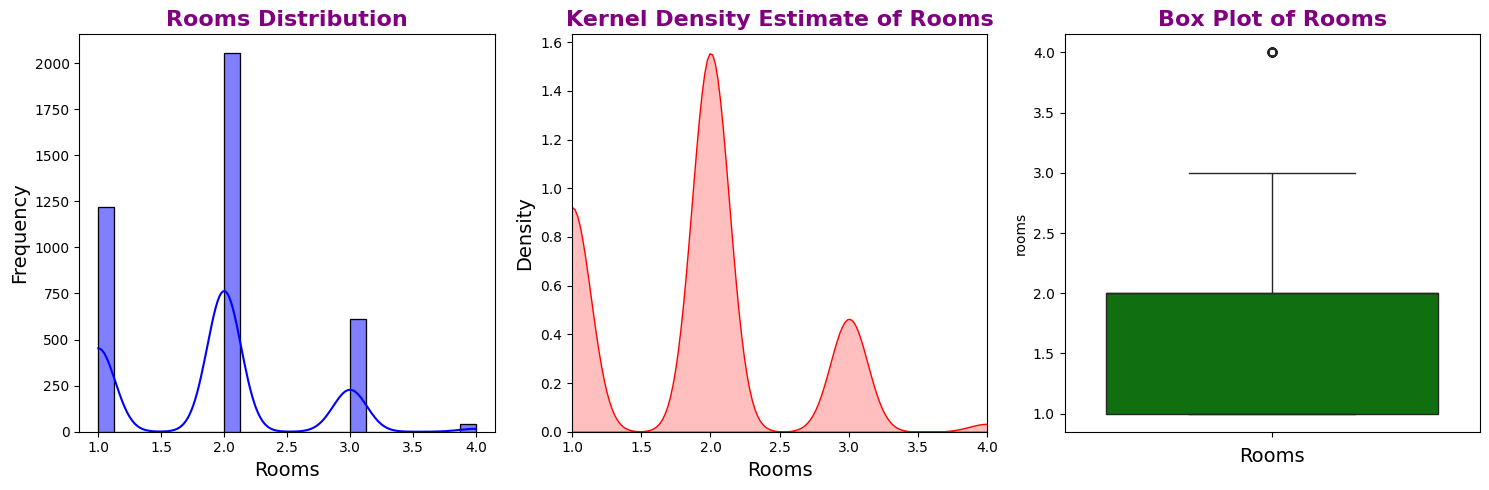

In [115]:
plot_hist_kde_box('rooms')

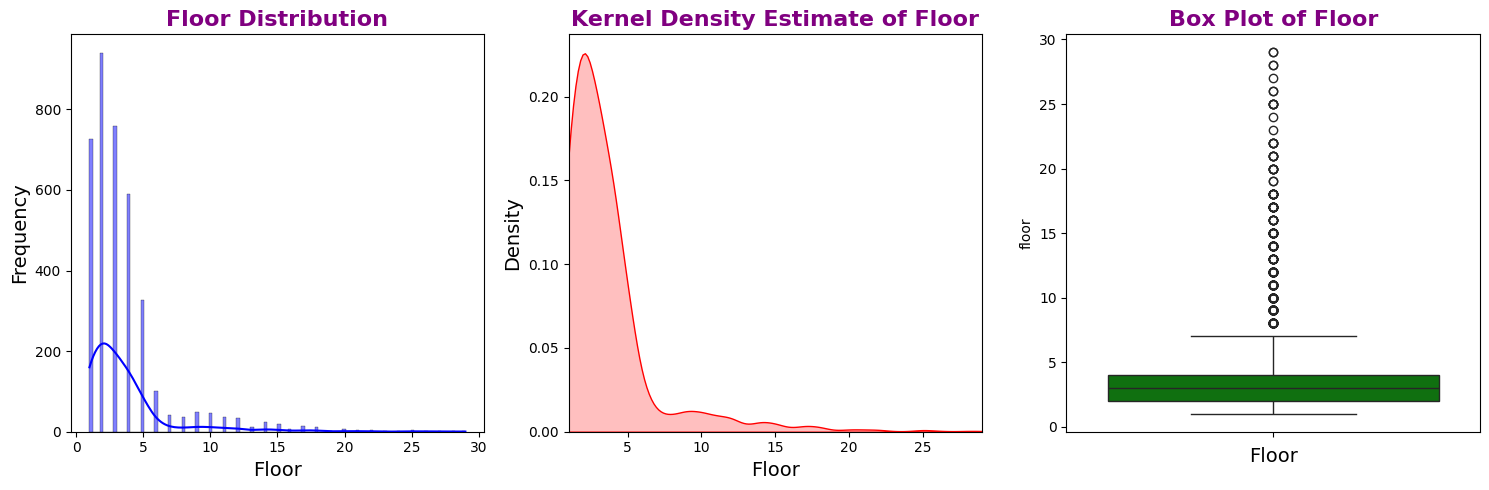

In [116]:
plot_hist_kde_box('floor')

In [117]:
def plot_pie_count(column_name, data=df):
    plt.figure(figsize=(10, 5))

    # Pie Plot
    plt.subplot(1, 2, 1)
    data[column_name].value_counts().rename(index={0: 'No', 1: 'Yes'}).plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
    plt.title(f'Distribution of {column_name.capitalize()}', fontsize=16, fontweight='bold', color='purple')
    plt.ylabel('')

    # Count Plot
    plt.subplot(1, 2, 2)
    sns.countplot(x=column_name, data=data, palette='viridis')
    plt.title(f'Count of {column_name.capitalize()}', fontsize=16, fontweight='bold', color='purple')
    plt.xlabel(column_name.capitalize(), fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.xticks([0, 1], ['False', 'True'])

    plt.tight_layout()
    plt.show()

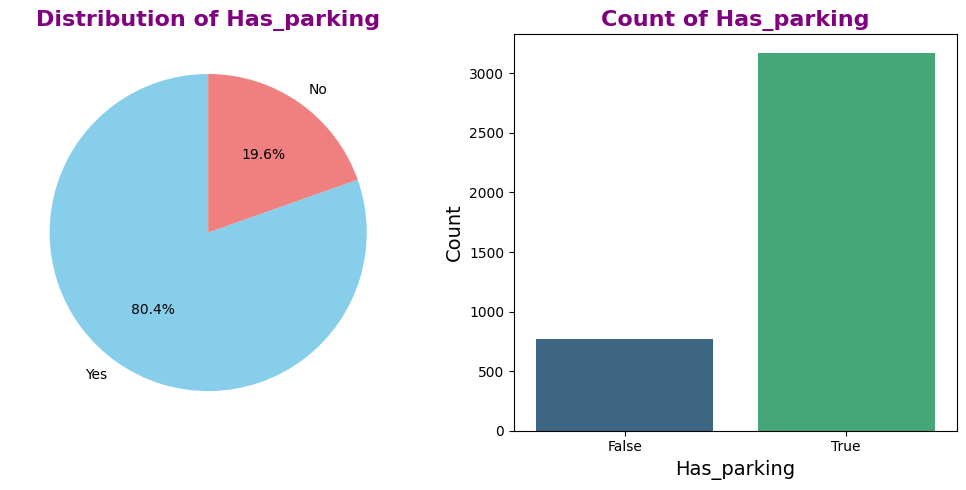

In [118]:
plot_pie_count('has_parking')

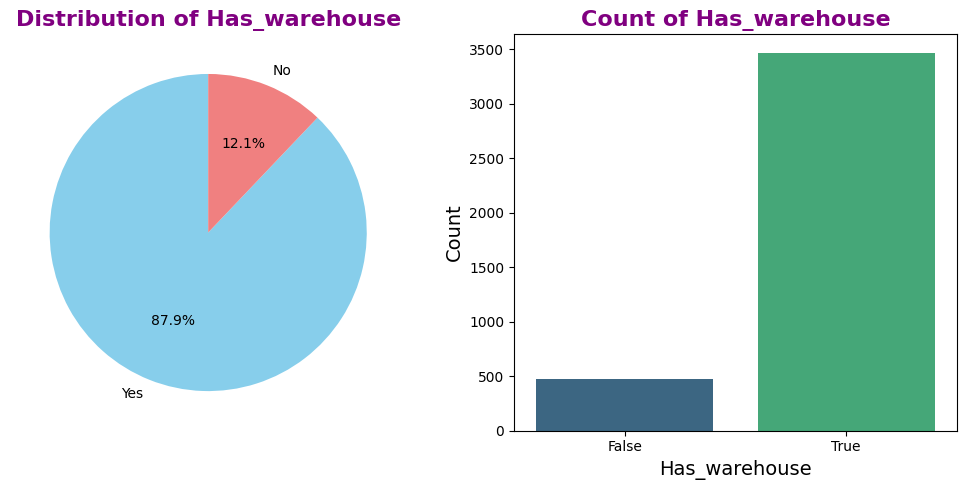

In [119]:
plot_pie_count('has_warehouse')

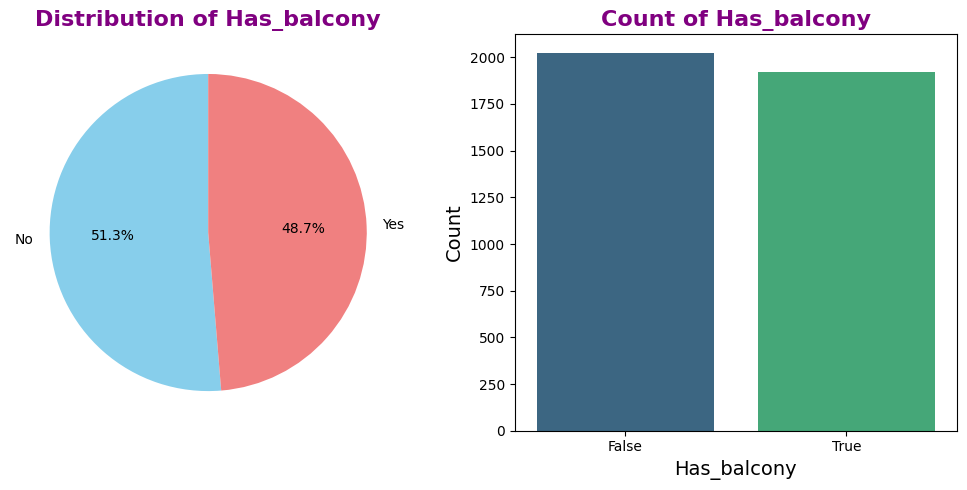

In [120]:
plot_pie_count('has_balcony')

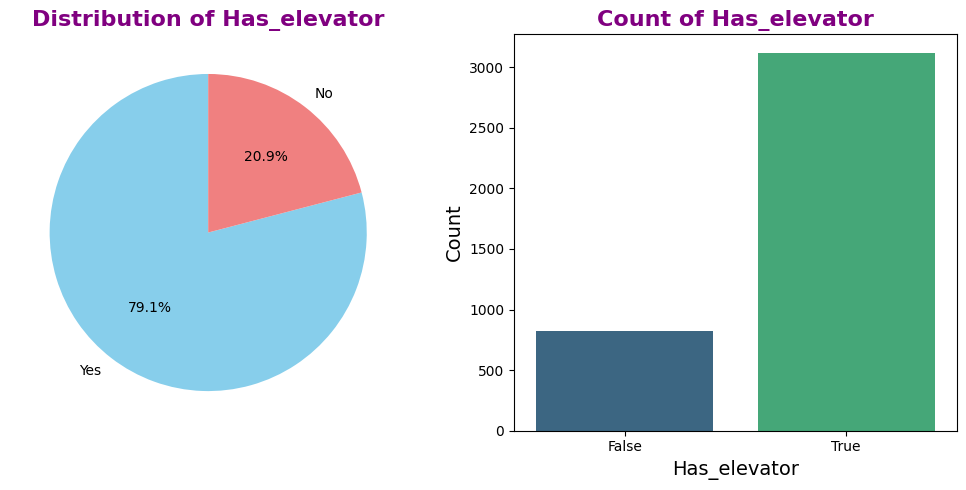

In [121]:
plot_pie_count('has_elevator')

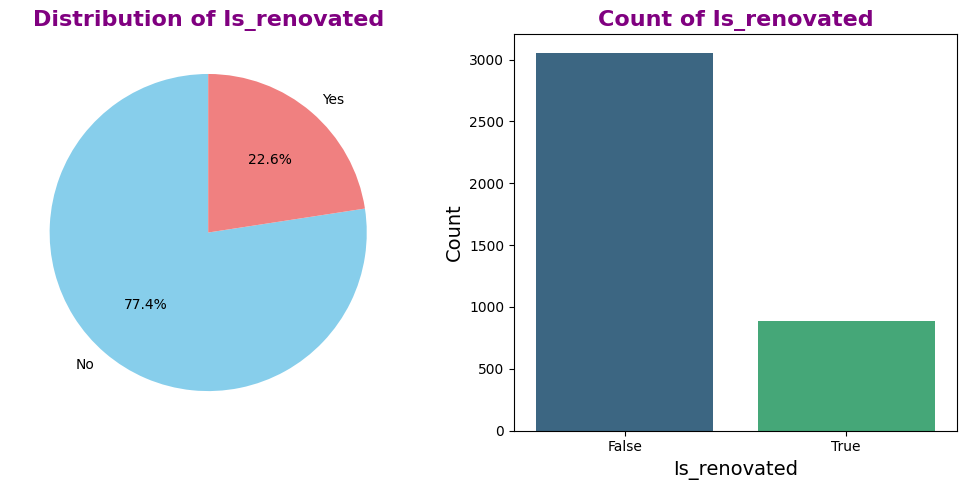

In [122]:
plot_pie_count('is_renovated')

In [123]:
def plot_scatter(x_column, y_column, data=df):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=x_column, y=y_column, data=data, color='b', alpha=0.5)
    plt.title(f'Scatter Plot of {x_column.capitalize()} vs {y_column.capitalize()}', fontsize=16, fontweight='bold', color='purple')
    plt.xlabel(x_column.capitalize(), fontsize=14)
    plt.ylabel(y_column.capitalize(), fontsize=14)
    plt.grid(True, alpha=0.2)
    plt.show()

In [124]:
filter_df = df[(df['price'] > 8e8) & (df['price'] < 15e10)]

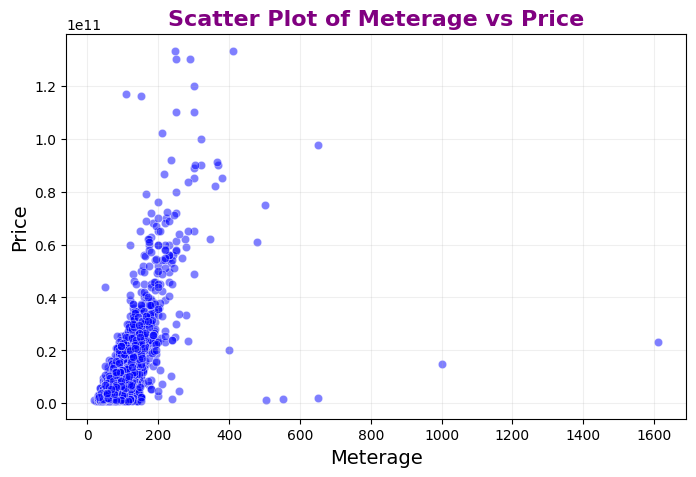

In [125]:
plot_scatter('meterage', 'price', data=filter_df)

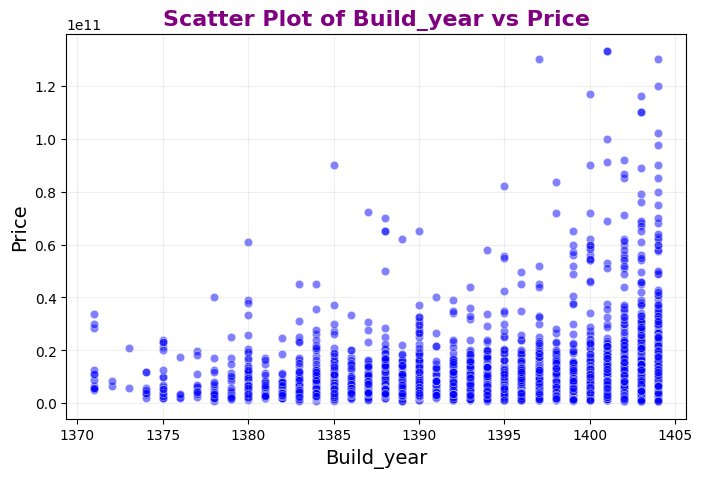

In [126]:
plot_scatter('build_year', 'price', data=filter_df)

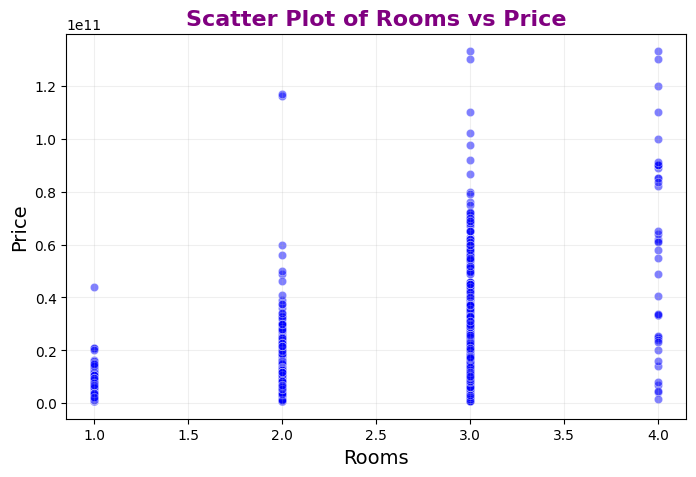

In [127]:
plot_scatter('rooms', 'price', data=filter_df)

In [128]:
def plot_binary_price_boxplot(column_name, data=df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=column_name, y='price', data=data, palette='viridis')
    plt.title(f'Price Distribution by {column_name.capitalize()}', fontsize=16, fontweight='bold', color='purple')
    plt.xlabel(column_name.capitalize(), fontsize=14)
    plt.ylabel("Price", fontsize=14)
    plt.xticks([0, 1], ['No', 'Yes'])
    plt.grid(axis='y', alpha=0.2)
    plt.show()

In [129]:
lower_10b = df[df['price'] < 10e9]

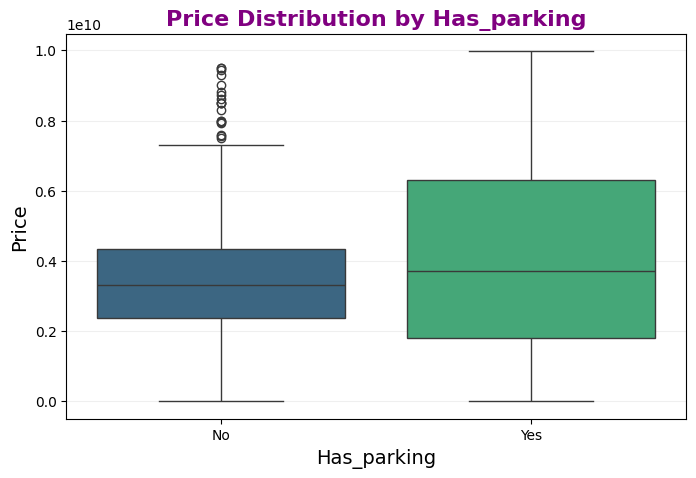

In [130]:
plot_binary_price_boxplot('has_parking', data=lower_10b)

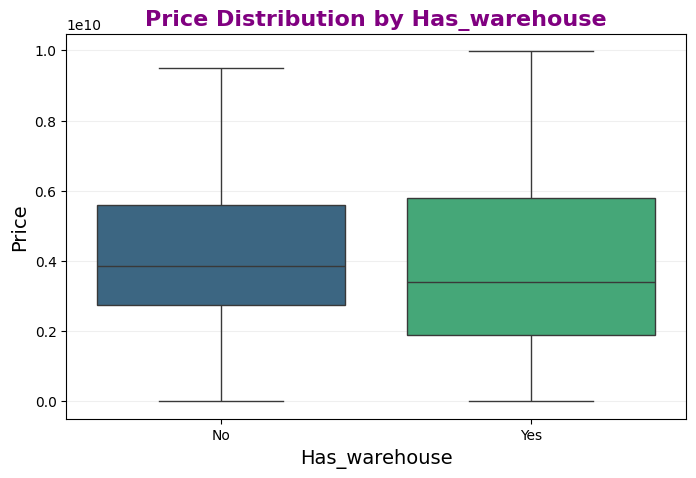

In [131]:
plot_binary_price_boxplot('has_warehouse', data=lower_10b)

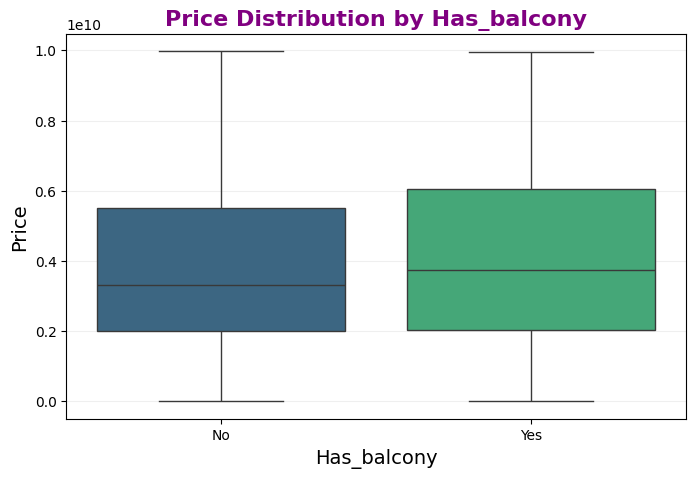

In [132]:
plot_binary_price_boxplot('has_balcony', data=lower_10b)

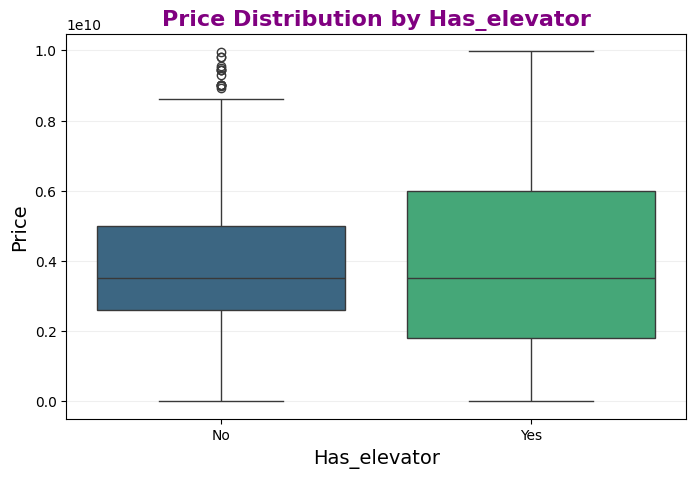

In [133]:
plot_binary_price_boxplot('has_elevator', data=lower_10b)

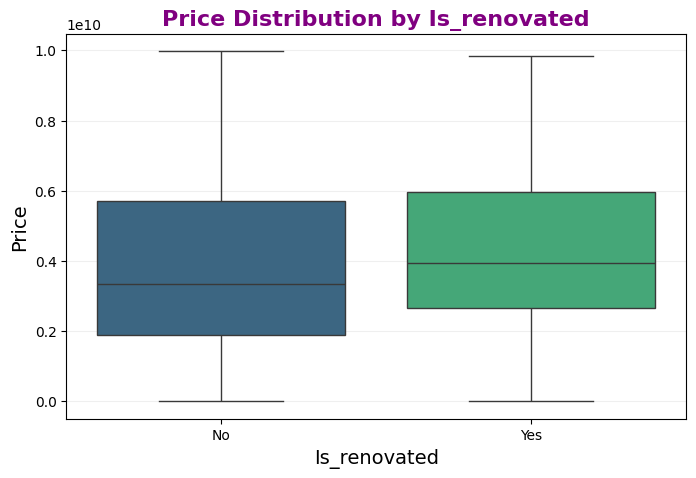

In [134]:
plot_binary_price_boxplot('is_renovated', data=lower_10b)

## Data Cleaning and Preprocessing

In [135]:
# Remove unnecessary columns
columns_to_remove = ['title', 'time_posted', 'scraped_time', 'price_per_meter', 'link']
if set(columns_to_remove).issubset(df.columns):
    df.drop(columns=columns_to_remove, axis=1, inplace=True)

In [136]:
custom_cols = ['build_year', 'rooms', 'floor']
df[custom_cols] = df[custom_cols].fillna(-1).astype(int)

In [137]:
class PriceCorrectionTransformer(BaseEstimator, TransformerMixin):
  def __init__(self, column='price'):
    self.column = column

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()
    correction_prices = []

    for price in X[self.column]:
      if price < 150e9:
        correction_prices.append(price)
      else:
        digits = len(str(int(price)))
        if digits >= 15:
          correction_prices.append(price / 1000)
        elif digits >= 14:
          correction_prices.append(price / 100)
        elif digits >= 13:
          correction_prices.append(price / 10)
        else:
          correction_prices.append(price)

    X[self.column] = correction_prices
    return X

In [138]:
# Apply price correction
df['price'] = PriceCorrectionTransformer().fit_transform(df)[['price']]
# Convert to Billion Toman for better readability
df['price'] /= 1e9
# Set unrealistic prices to NaN to be imputed later
df.loc[(df['price'] > 150) | (df['price'] < 0.8), 'price'] = np.nan

In [139]:
# Impute missing prices using KNN
df_impute = df.select_dtypes(exclude=['object']).copy()
knn_imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(knn_imputer.fit_transform(df_impute), columns=df_impute.columns)
df['price'] = df_imputed['price']

In [140]:
X = df.drop(['price'] , axis=1)
y = df['price']

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [142]:
# Apply Log Transform to the target variable
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [143]:
print(f'Number of rows in training set: {X_train.shape[0]}')
print(f'Number of rows in testing set: {X_test.shape[0]}')

Number of rows in training set: 3152
Number of rows in testing set: 789


In [144]:
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
  def __init__(self, current_year=1404):
    self.current_year = current_year
    self.location_max_floor_ = None

  def fit(self, X, y=None):
    X_ = X.copy()
    self.feature_names_in_ = X.columns
    X_['floor'] = X_['floor'].replace(-1, np.nan)
    self.location_max_floor_ = X_.groupby('location')['floor'].max()
    return self

  def transform(self, X):
    X_ = X.copy()
    # Basic Features
    X_['age'] = self.current_year - X_['build_year']
    X_['age'] = X_['age'].apply(lambda x: x if 0 <= x <= 50 else np.nan)

    # Handle division by zero for rooms
    X_['room_density'] = X_['meterage'] / X_['rooms'].replace(0, 1)

    # Feature: floor_is_top
    X_['floor_is_top'] = (X_['floor'] == X_['location'].map(self.location_max_floor_)).astype(int)

    # Feature: age_bucket
    age_bins = [-1, 5, 15, 30, 200]
    age_labels = ['0-5', '6-15', '16-30', '30+']
    X_['age_bucket'] = pd.cut(X_['age'], bins=age_bins, labels=age_labels, right=True)

    # Feature: rooms_per_floor
    X_['rooms_per_floor'] = X_['rooms'] / (X_['floor'] + 1)

    # Feature: density_level
    try:
        density_bins = pd.qcut(X_['room_density'], q=4, labels=False, duplicates='drop')
        density_labels = ['low', 'medium', 'high', 'very_high']
        X_['density_level'] = pd.cut(X_['room_density'], bins=pd.qcut(X_['room_density'], q=4, retbins=True, duplicates='drop')[1], labels=density_labels, include_lowest=True)
    except ValueError: # Handle cases with not enough unique values for qcut
        X_['density_level'] = 'medium'

    # Make rare locations 'Other'
    location_counts = X_['location'].value_counts()
    rare_locations = location_counts[location_counts <= 20].index
    X_['location'] = X_['location'].replace(rare_locations, 'Other')

    return X_

In [145]:
class LocationFeaturesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, north=None, south=None, east=None, west=None, center=None):
        self.north = north or []
        self.south = south or []
        self.east = east or []
        self.west = west or []
        self.center = center or []
        self.region_encoder = ce.TargetEncoder(smoothing=5)
        self.district_encoder = ce.TargetEncoder(smoothing=5)

    def fit(self, X, y=None):
        X_ = X.copy()
        X_['district'] = X_['location'].apply(self._extract_district)
        X_['region'] = X_['district'].apply(self._map_region)

        self.region_encoder.fit(X_['region'], y)
        self.district_encoder.fit(X_['district'], y)
        return self

    def transform(self, X):
        X_ = X.copy()
        X_['district'] = X_['location'].apply(self._extract_district)
        X_['region'] = X_['district'].apply(self._map_region)

        region_encoded = self.region_encoder.transform(X_['region'])
        district_encoded = self.district_encoder.transform(X_['district'])

        result = pd.concat([X_.drop(['location', 'district', 'region'], axis=1), region_encoded, district_encoded], axis=1)
        result.columns = X_.drop(['location', 'district', 'region'], axis=1).columns.tolist() + ['region_encoded', 'district_encoded']
        return result

    def _extract_district(self, loc):
        try:
            return loc.split('،')[1].strip()
        except:
            return 'Other'

    def _map_region(self, district):
        if district in self.north: return 'north'
        if district in self.south: return 'south'
        if district in self.east: return 'east'
        if district in self.west: return 'west'
        if district in self.center: return 'center'
        return 'unknown'

In [146]:
class ReplaceMinusOneWithNanTransformer(BaseEstimator, TransformerMixin):
  def __init__(self, columns):
        self.columns = columns
  def fit(self, X, y=None): return self
  def transform(self, X):
      X_ = X.copy()
      for col in self.columns:
          X_[col] = X_[col].replace(-1, np.nan)
      return X_


In [147]:
class OutlierCapperIQR(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns
        self.bounds_ = {}

    def fit(self, X, y=None):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.columns)

        for col in self.columns:
            Q1 = X_df[col].quantile(0.25)
            Q3 = X_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            self.bounds_[col] = (lower_bound, upper_bound)

        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy_df = X_copy if isinstance(X_copy, pd.DataFrame) else pd.DataFrame(X_copy, columns=self.columns)

        for col in self.columns:
            lower, upper = self.bounds_[col]
            X_copy_df[col] = X_copy_df[col].clip(lower=lower, upper=upper)

        return X_copy_df

    def get_feature_names_out(self, input_features=None):
        return input_features

In [148]:
if set(['price_flag']).issubset(df.columns):
  df.drop(['price_flag'], axis=1, inplace=True)

In [149]:
X = df.drop(['price'] , axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [150]:
print(f'Number of rows in training set: {X_train.shape[0]}')
print(f'Number of rows in testing set: {X_test.shape[0]}')

Number of rows in training set: 3152
Number of rows in testing set: 789


In [151]:
north = ["نیاوران", "فرمانیه", "اقدسیه", "قیطریه", "زعفرانیه", "الهیه", "جماران", "اوین", "ولنجک", "دزاشیب", "کاشانک", "دارآباد", "سعدآباد", "جمشیدیه"]
south = ["نازی‌آباد", "خانی‌آباد نو", "شوش", "مولوی", "جوادیه", "راه‌آهن", "افسریه", "شاپور", "منیریه", "بازار", "بیسیم", "خراسان", "ظهیرآباد", "آذری", "دولت‌آباد"]
east = ["تهران‌نو", "تهرانپارس", "حکیمیه", "مجیدیه", "نارمک", "پیروزی", "دروس", "امامت", "هنگام", "نیروی هوایی", "لویزان", "سیدخندان", "تهران‌پارس غربی", "تهران‌پارس شرقی"]
west = ["پونک", "صادقیه", "جنت‌آباد", "سازمان برنامه", "چیتگر", "شهر زیبا", "شهران", "ستارخان", "تهرانسر", "اکباتان", "شهرک غرب", "کوی فردوس", "شهرک راه‌آهن", "شهرک ژاندارمری", "وردآورد"]
center = ["ونک", "یوسف‌آباد", "بلوار کشاورز", "جمال‌زاده", "کریم‌خان", "جمهوری", "انقلاب", "فاطمی", "امیرآباد", "عباس‌آباد", "آرژانتین", "هفت تیر", "میدان ولیعصر", "بخارست", "بریانک"]
unknown = ["Other"]

In [152]:
numeric_features = ['meterage', 'build_year', 'rooms', 'floor', 'age', 'room_density', 'rooms_per_floor']
binary_features = ['has_parking', 'has_warehouse', 'has_balcony', 'has_elevator', 'is_renovated', 'floor_is_top']
categorical_features = ['age_bucket', 'density_level']
location_feature = ['location']

In [153]:
numeric_pipeline = Pipeline([
    ('capper', OutlierCapperIQR(columns=['meterage'])),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


# Create the main preprocessor using ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('bin', 'passthrough', binary_features),
    ('cat', categorical_pipeline, categorical_features),
    # Location is handled in the final step to allow target encoding
])


# Create the full data processing pipeline
base_pipeline = Pipeline([
    ('replace_neg1', ReplaceMinusOneWithNanTransformer(columns=['build_year', 'rooms', 'floor'])),
    ('feature_engineering', FeatureEngineeringTransformer()),
    ('preprocessor', preprocessor),
])

# Fit and transform the training data using the base pipeline
X_train_base = base_pipeline.fit_transform(X_train, y_train_log)
X_test_base = base_pipeline.transform(X_test)

ohe_feature_names = base_pipeline.named_steps['preprocessor'].named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features)
base_feature_names = numeric_features + binary_features + ohe_feature_names.tolist()
X_train_base_df = pd.DataFrame(X_train_base, columns=base_feature_names, index=X_train.index)
X_test_base_df = pd.DataFrame(X_test_base, columns=base_feature_names, index=X_test.index)

In [154]:
X_train_for_loc = X_train_base_df.join(X_train['location'])
X_test_for_loc = X_test_base_df.join(X_test['location'])
loc_encoder = LocationFeaturesTransformer(north=north, south=south, east=east, west=west, center=center)
X_train_prepared = loc_encoder.fit_transform(X_train_for_loc, y_train_log)
X_test_prepared = loc_encoder.fit_transform(X_test_for_loc, y_test_log)

In [155]:
print("Final training data shape:", X_train_prepared.shape)
print("Final test data shape:", X_test_prepared.shape)

Final training data shape: (3152, 25)
Final test data shape: (789, 25)


In [156]:
X_train_prepared.head()

,meterage,build_year,rooms,floor,age,room_density,rooms_per_floor,has_parking,has_warehouse,has_balcony,...,age_bucket_30+,age_bucket_6-15,age_bucket_nan,density_level_high,density_level_low,density_level_medium,density_level_very_high,density_level_nan,region_encoded,district_encoded
3752,-0.33,-0.92,0.00,-1.00,0.92,-1.13,1.50,1.00,1.00,0.00,...,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.92,2.62
1188,0.25,-0.46,0.00,-0.50,0.46,-0.20,0.50,1.00,1.00,0.00,...,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.94,2.00
3364,1.02,0.46,1.00,1.00,-0.46,-0.38,0.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.94,2.30
1926,-0.62,-0.92,-1.00,-0.50,0.92,0.00,-0.50,0.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.94,1.67
3578,-0.38,0.38,-1.00,9.50,-0.38,0.80,-1.37,1.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.94,1.68


In [157]:
X_train_prepared.columns

Index(['meterage', 'build_year', 'rooms', 'floor', 'age', 'room_density',
       'rooms_per_floor', 'has_parking', 'has_warehouse', 'has_balcony',
       'has_elevator', 'is_renovated', 'floor_is_top', 'age_bucket_0-5',
       'age_bucket_16-30', 'age_bucket_30+', 'age_bucket_6-15',
       'age_bucket_nan', 'density_level_high', 'density_level_low',
       'density_level_medium', 'density_level_very_high', 'density_level_nan',
       'region_encoded', 'district_encoded'],
      dtype='object')

In [158]:
def evaluate_regression_model(y_true, y_pred_log, model_name="Regression Model"):
    """
    Evaluates a regression model.
    Assumes y_pred is in log scale and converts it back before evaluation.
    y_true is the original, non-log-transformed data.
    """
    # Inverse transform the predictions to get actual prices
    y_pred_actual = np.expm1(y_pred_log)

    # Ensure y_true is in the correct format
    y_true_actual = y_true.copy()

    mae = mean_absolute_error(y_true_actual, y_pred_actual)
    mse = mean_squared_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_actual, y_pred_actual)

    print(f"--- Evaluation Metrics for {model_name} (on original scale) ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f} (Billion Toman)")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f} (Billion Toman)")
    print(f"R-squared (R2): {r2 * 100:.2f}%")
    print('\n')

## Data Visualization

In [159]:
df_viz = X_train_prepared.copy()
df_viz['price_in_billion'] = y_train.values

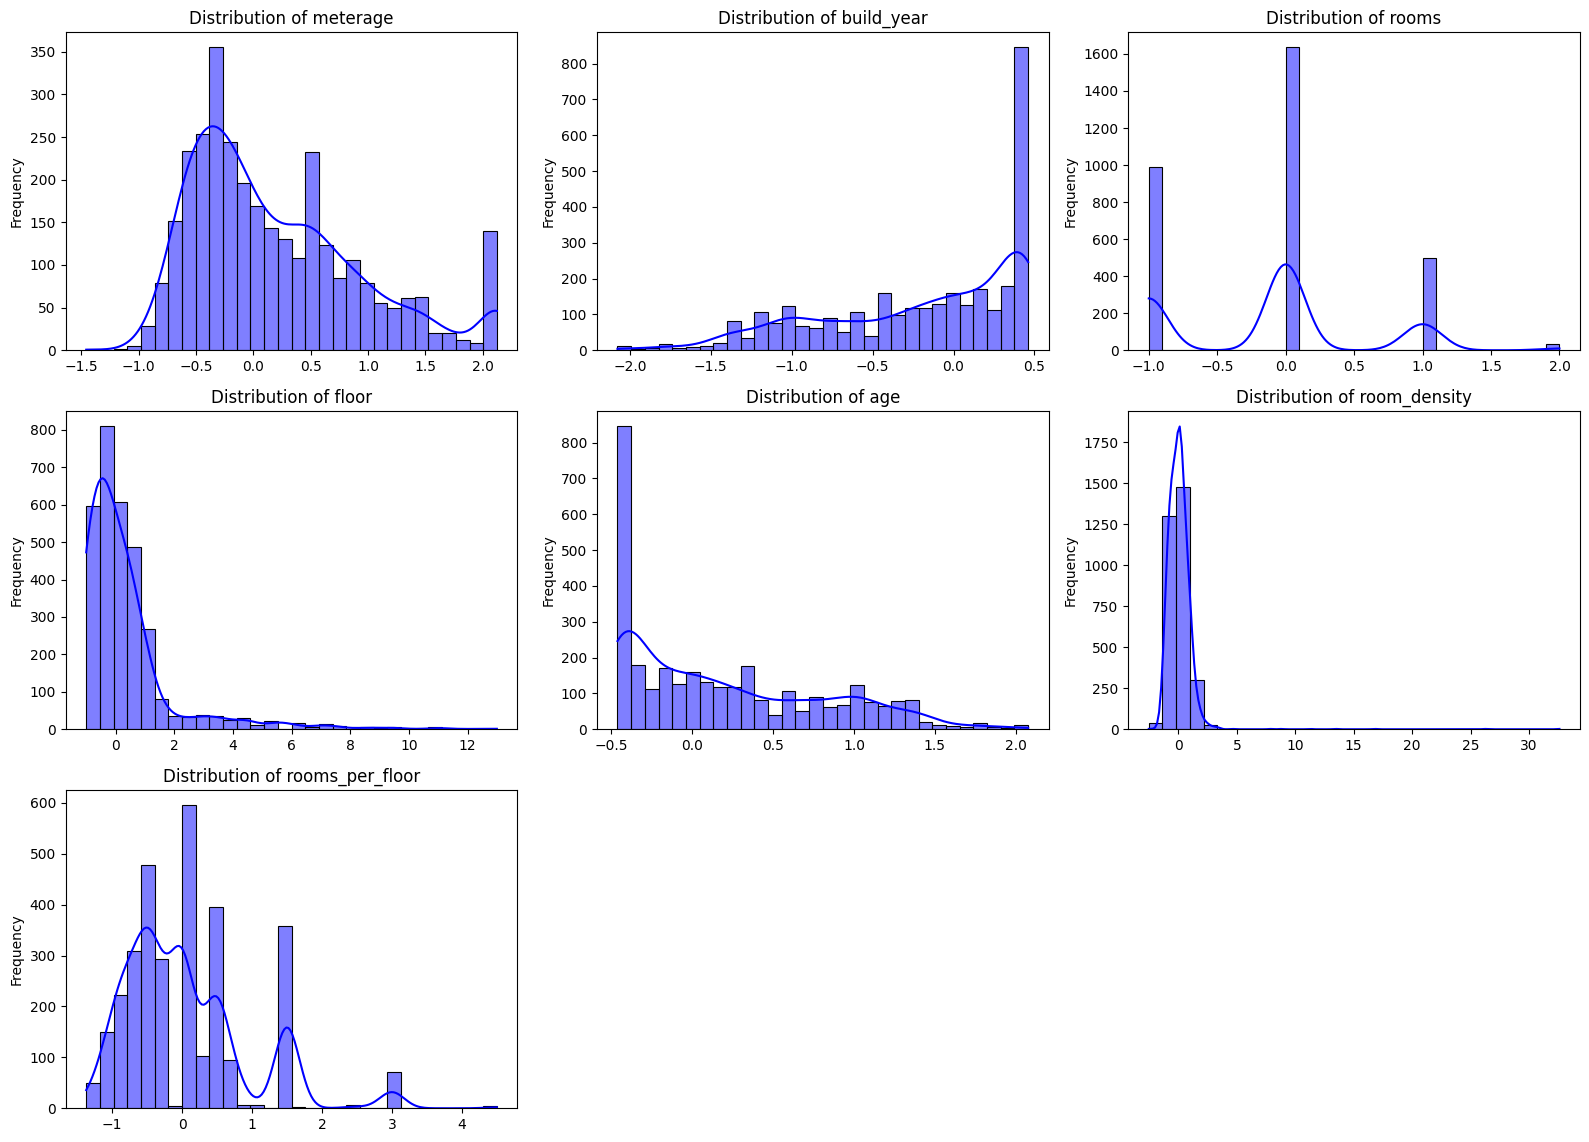

In [160]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df_viz[col], kde=True, bins=30, color='b')
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('Frequency')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


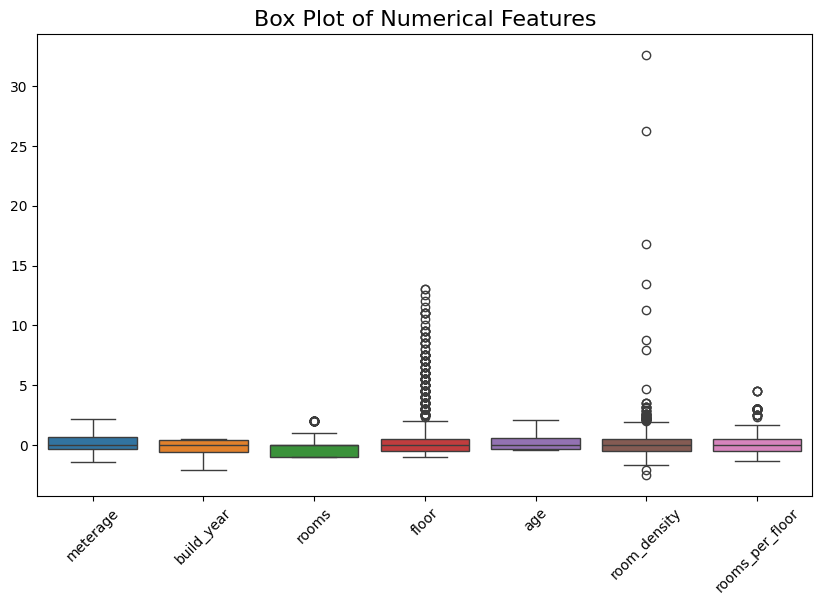

In [161]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_viz[numeric_features])
plt.title('Box Plot of Numerical Features', fontsize=16)
plt.xticks(rotation=45)
plt.show()

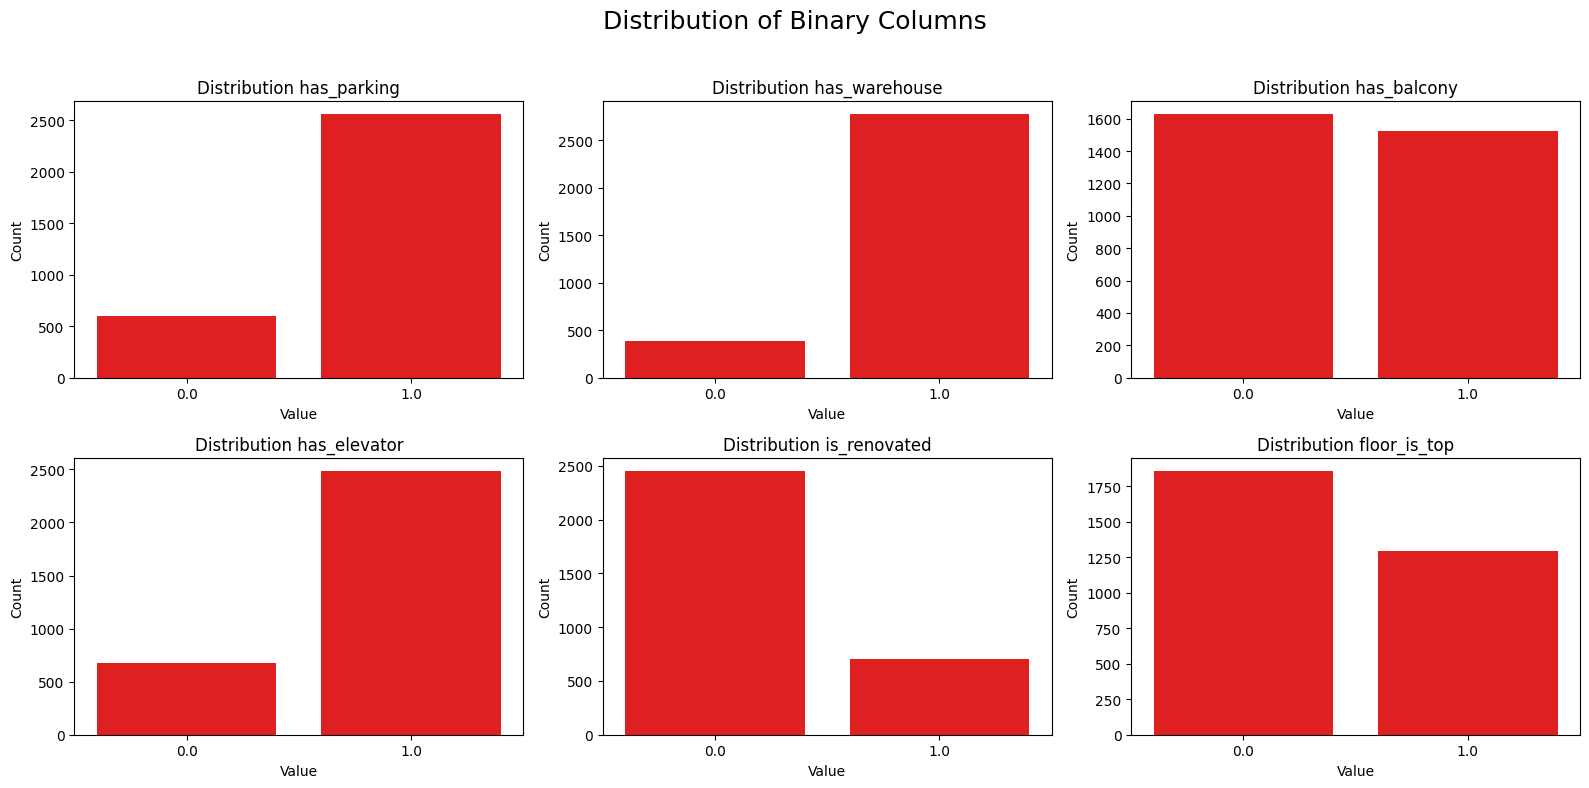

In [162]:
plt.figure(figsize=(16, 8))
plt.suptitle('Distribution of Binary Columns', fontsize=18)
for i, col in enumerate(binary_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df_viz, color='r')
    plt.title(f'Distribution {col}')
    plt.xlabel('Value')
    plt.ylabel('Count')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

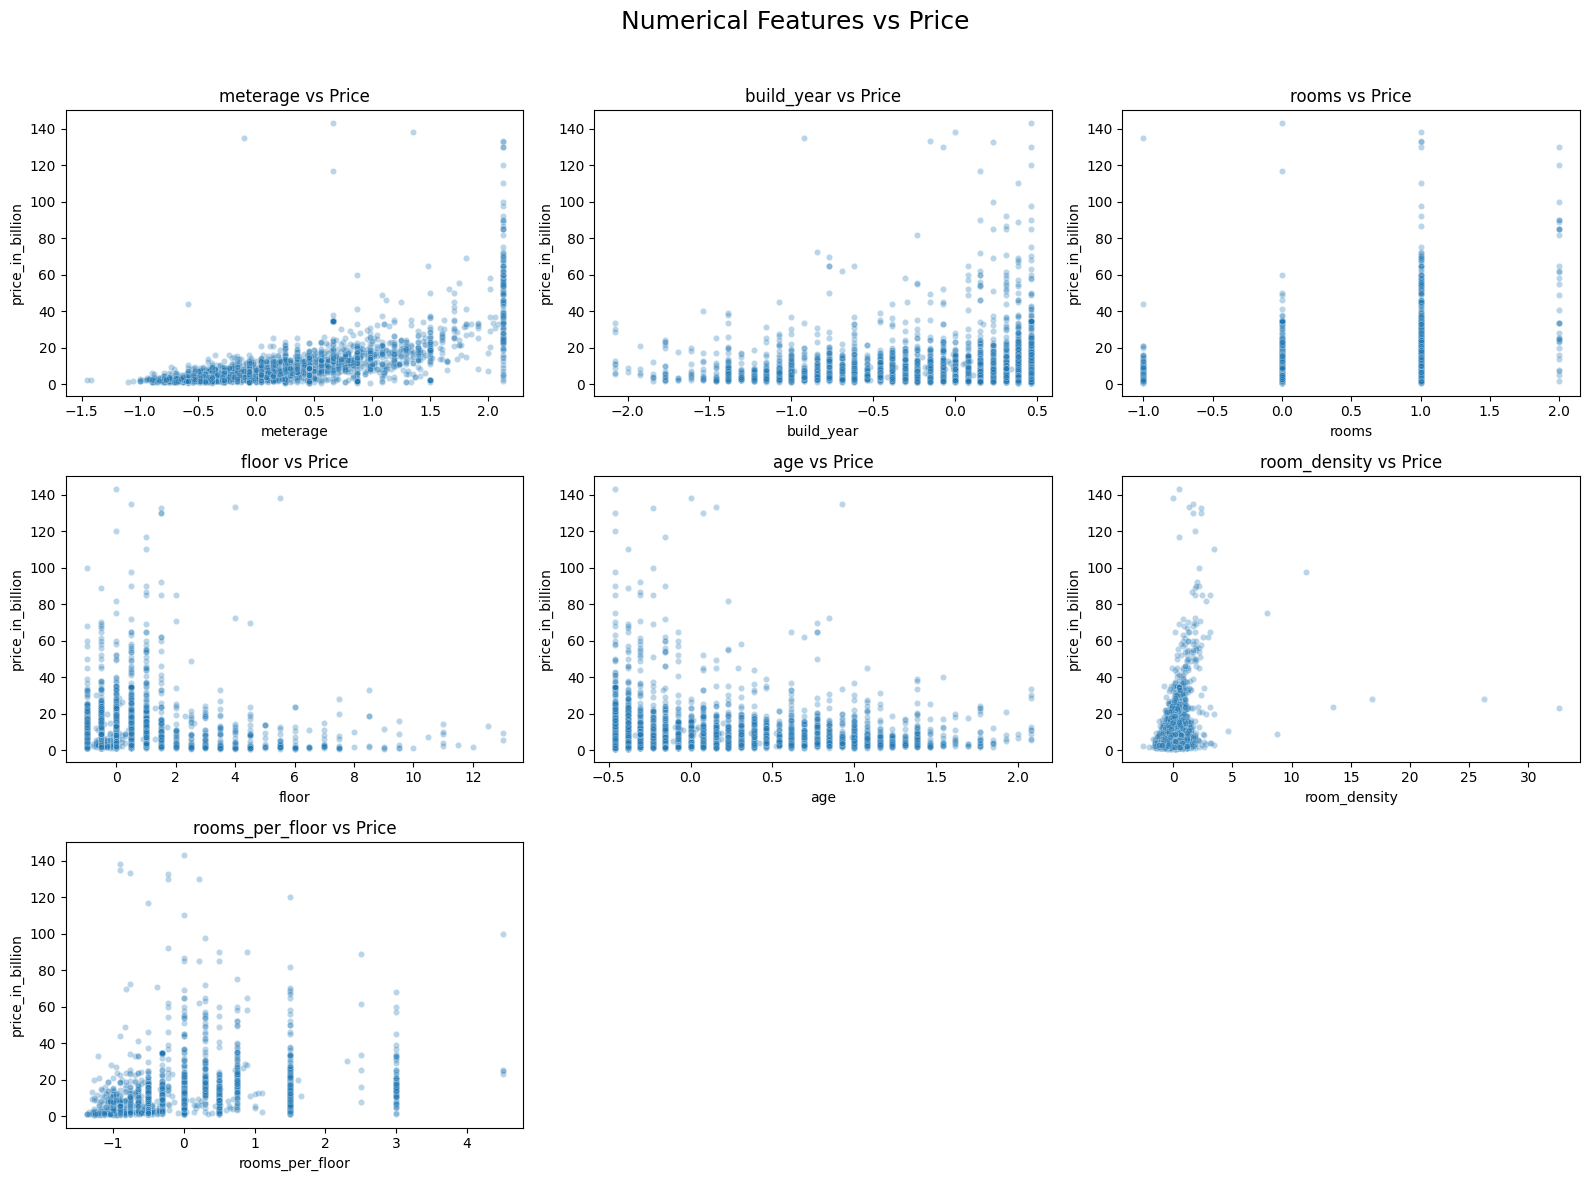

In [163]:
plt.figure(figsize=(16, 12))
plt.suptitle('Numerical Features vs Price', fontsize=18)
for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(x=col, y='price_in_billion', data=df_viz, alpha=0.3, s=20)
    plt.title(f'{col} vs Price')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

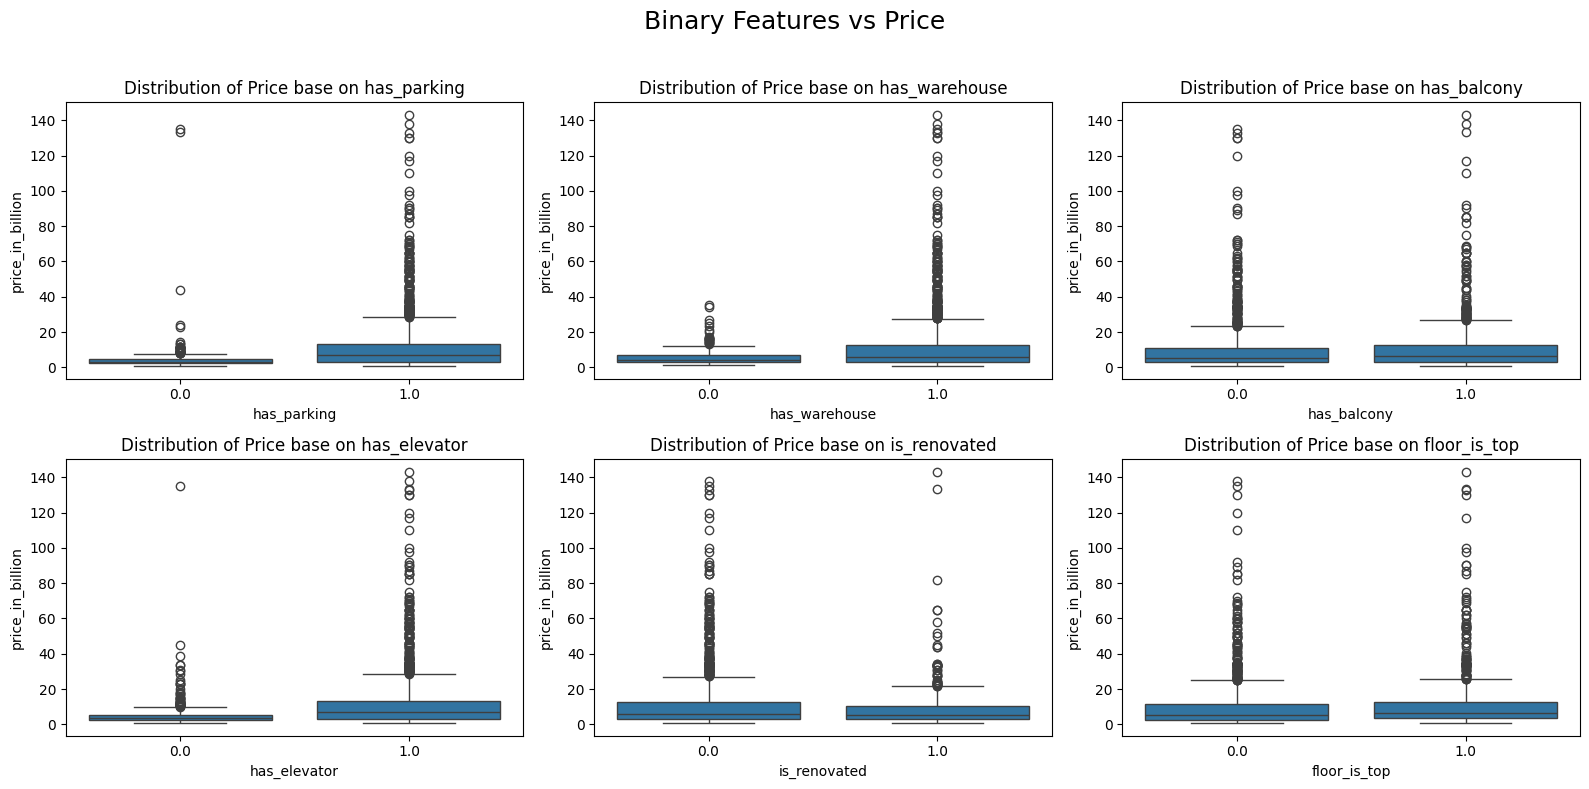

In [164]:
plt.figure(figsize=(16, 8))
plt.suptitle('Binary Features vs Price', fontsize=18)
for i, col in enumerate(binary_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=col, y='price_in_billion', data=df_viz)
    plt.title(f'Distribution of Price base on {col}')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

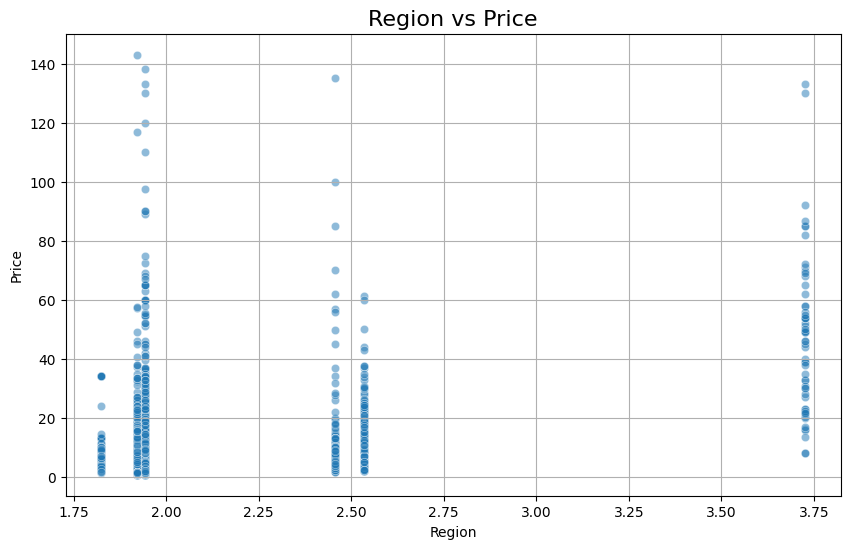

In [165]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='region_encoded', y='price_in_billion', data=df_viz, alpha=0.5)
plt.title('Region vs Price', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Price')
plt.grid(True)
plt.show()

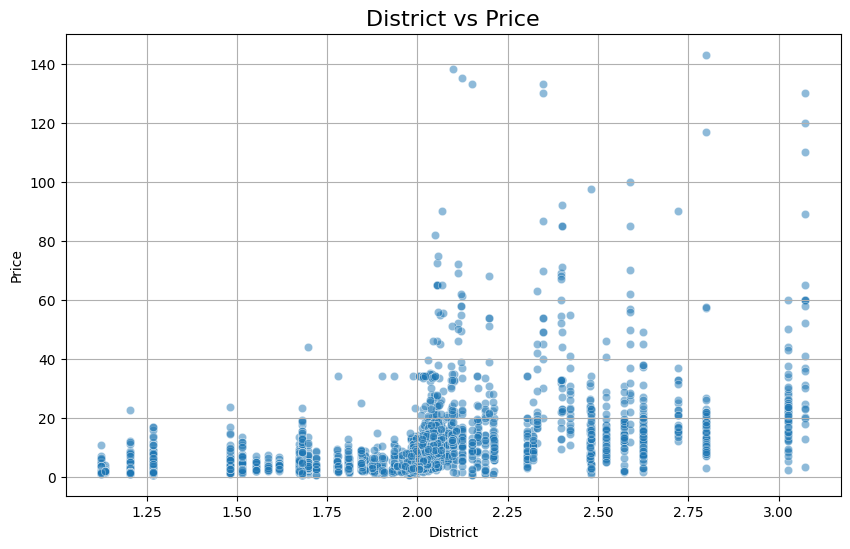

In [166]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='district_encoded', y='price_in_billion', data=df_viz, alpha=0.5)
plt.title('District vs Price', fontsize=16)
plt.xlabel('District')
plt.ylabel('Price')
plt.grid(True)
plt.show()

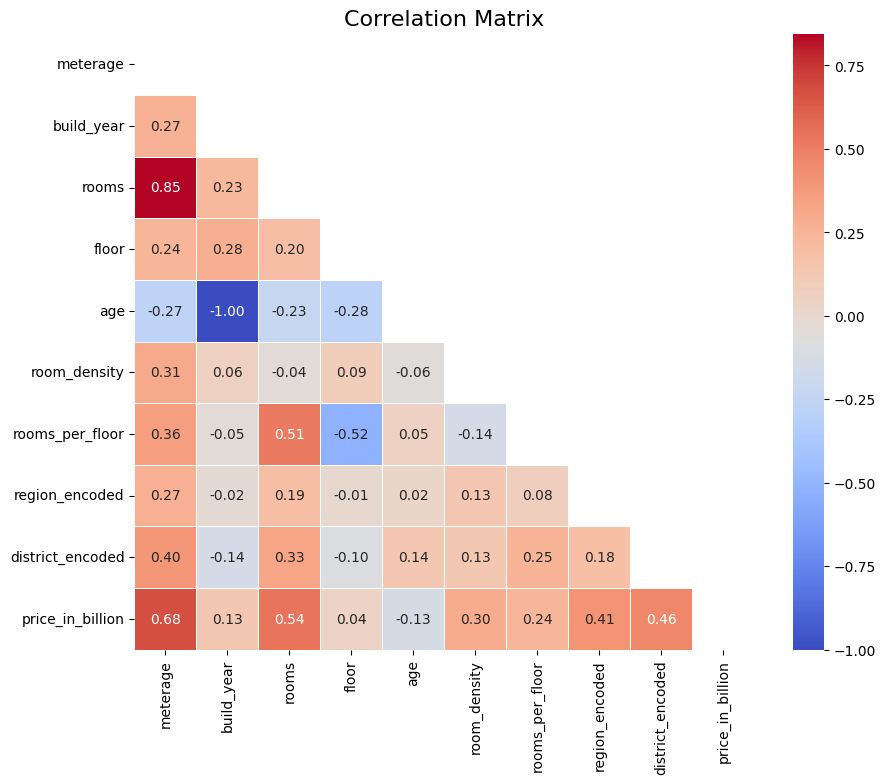

In [167]:
correlation_cols = numeric_features + ['region_encoded', 'district_encoded', 'price_in_billion']
correlation_matrix = df_viz[correlation_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [168]:
correlation_matrix['price_in_billion'].sort_values(ascending=False)

,price_in_billion
price_in_billion,1.00
meterage,0.68
rooms,0.54
district_encoded,0.46
region_encoded,0.41
room_density,0.30
rooms_per_floor,0.24
build_year,0.13
floor,0.04
age,-0.13


## Modeling (if applicable)

In [169]:
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_prepared, y_train_log)

Training Random Forest Regressor...


RandomForestRegressor(max_depth=20, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [170]:
y_pred_log_rf = rf_model.predict(X_test_prepared)
evaluate_regression_model(y_test, y_pred_log_rf, model_name="Random Forest Regressor")

--- Evaluation Metrics for Random Forest Regressor (on original scale) ---
Mean Absolute Error (MAE): 3.6593 (Billion Toman)
Root Mean Squared Error (RMSE): 8.6825 (Billion Toman)
R-squared (R2): 65.53%




In [171]:
print("Training XGBoost Regressor...")
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=7, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_prepared, y_train_log)

Training XGBoost Regressor...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [172]:
y_pred_log_xgb = xgb_model.predict(X_test_prepared)
evaluate_regression_model(y_test, y_pred_log_xgb, model_name="XGBoost Regressor")

--- Evaluation Metrics for XGBoost Regressor (on original scale) ---
Mean Absolute Error (MAE): 3.8747 (Billion Toman)
Root Mean Squared Error (RMSE): 8.8785 (Billion Toman)
R-squared (R2): 63.95%




In [173]:
print("Training HistGradientBoosting Regressor...")
hist_model = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, max_depth=7, random_state=42)
hist_model.fit(X_train_prepared, y_train_log)

Training HistGradientBoosting Regressor...


HistGradientBoostingRegressor(learning_rate=0.05, max_depth=7, max_iter=500,
                              random_state=42)

In [174]:
y_pred_log_hist = hist_model.predict(X_test_prepared)
evaluate_regression_model(y_test, y_pred_log_hist, model_name="HistGradientBoosting Regressor")

--- Evaluation Metrics for HistGradientBoosting Regressor (on original scale) ---
Mean Absolute Error (MAE): 3.8495 (Billion Toman)
Root Mean Squared Error (RMSE): 9.2197 (Billion Toman)
R-squared (R2): 61.13%




In [175]:
# Feature importances from Random Forest
importances = rf_model.feature_importances_
features = X_train_prepared.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

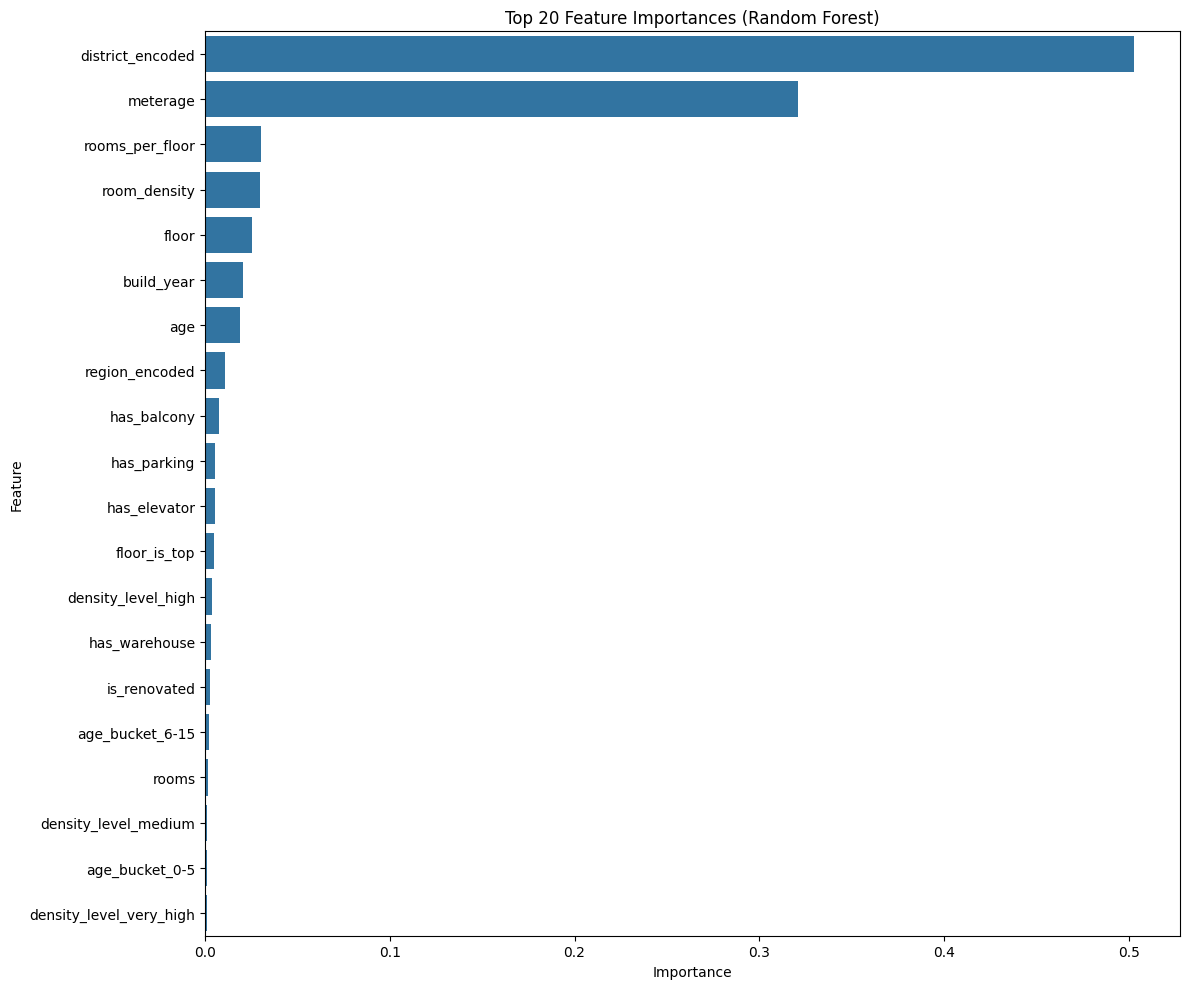

In [176]:
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Fine Tuning the model

In [177]:
# --- Model 1: Random Forest Regressor ---
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_prepared, y_train_log)
y_pred_log_rf = rf_model.predict(X_test_prepared)
evaluate_regression_model(y_test, y_pred_log_rf, model_name="Random Forest Regressor")

Training Random Forest Regressor...
--- Evaluation Metrics for Random Forest Regressor (on original scale) ---
Mean Absolute Error (MAE): 3.6593 (Billion Toman)
Root Mean Squared Error (RMSE): 8.6825 (Billion Toman)
R-squared (R2): 65.53%




In [178]:
# --- Model 2: XGBoost Regressor (Initial) ---
print("Training XGBoost Regressor (Initial)...")
xgb_model_initial = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=7, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_model_initial.fit(X_train_prepared, y_train_log)
y_pred_log_xgb_initial = xgb_model_initial.predict(X_test_prepared)
evaluate_regression_model(y_test, y_pred_log_xgb_initial, model_name="XGBoost Regressor (Initial)")

Training XGBoost Regressor (Initial)...
--- Evaluation Metrics for XGBoost Regressor (Initial) (on original scale) ---
Mean Absolute Error (MAE): 3.8747 (Billion Toman)
Root Mean Squared Error (RMSE): 8.8785 (Billion Toman)
R-squared (R2): 63.95%




In [179]:
param_grid = {
    'n_estimators': [400, 500],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 0.9]
}

xgb_model_for_tuning = XGBRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(estimator=xgb_model_for_tuning, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='neg_mean_squared_error', verbose=2)

grid_search.fit(X_train_prepared, y_train_log)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [5, 7],
                         'n_estimators': [400, 500], 'subsample': [0.8, 0.9]},
             scoring='neg_mean_squared_error', verbose=2)

In [180]:
best_xgb_model = grid_search.best_estimator_
print("Best Parameters found: ", grid_search.best_params_)

Best Parameters found:  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}


In [181]:
y_pred_log_xgb_tuned = best_xgb_model.predict(X_test_prepared)
evaluate_regression_model(y_test, y_pred_log_xgb_tuned, model_name="XGBoost Regressor (Tuned)")

--- Evaluation Metrics for XGBoost Regressor (Tuned) (on original scale) ---
Mean Absolute Error (MAE): 3.7082 (Billion Toman)
Root Mean Squared Error (RMSE): 8.5224 (Billion Toman)
R-squared (R2): 66.79%




In [182]:
ensemble_pred_log = (y_pred_log_rf + y_pred_log_xgb_tuned) / 2
evaluate_regression_model(y_test, ensemble_pred_log, model_name="Ensemble (RF + Tuned XGBoost)")


--- Evaluation Metrics for Ensemble (RF + Tuned XGBoost) (on original scale) ---
Mean Absolute Error (MAE): 3.6385 (Billion Toman)
Root Mean Squared Error (RMSE): 8.5450 (Billion Toman)
R-squared (R2): 66.61%




## Saving the models

In [183]:
# Saving the models
print("Saving components for prediction...")
joblib.dump(base_pipeline, 'base_pipeline.pkl')
joblib.dump(loc_encoder, 'location_encoder.pkl')
joblib.dump(base_feature_names, 'base_feature_names.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(best_xgb_model, 'best_xgb_model.pkl')
joblib.dump(grid_search, 'grid_search_rf.pkl')
print("All components saved successfully!")

# Loading models
# best_xgb_model = joblib.load('best_xgb_model.pkl')
# ensemble_model = joblib.load('ensemble_model.pkl')
# grid_search_rf = joblib.load('grid_search_rf.pkl')
# full_pipeline = joblib.load('full_pipeline.pkl')

Saving components for prediction...
All components saved successfully!


## Results and Discussion

### Result 1:

## Conclusion

### Column Descriptions

Here's a description of each column in the dataset:

*   **title**: The title of the property listing, often containing key details about the house.
*   **location**: The geographical location or neighborhood of the property within Tehran.
*   **time_posted**: The timestamp indicating when the property listing was posted.
*   **scraped_time**: The timestamp indicating when the data for this listing was collected.
*   **meterage**: The size of the property in square meters.
*   **build_year**: The year the property was built.
*   **rooms**: The number of rooms in the property.
*   **floor**: The floor number of the property in a building.
*   **has_parking**: A boolean or categorical indicator if the property has parking availability.
*   **has_warehouse**: A boolean or categorical indicator if the property has a warehouse or storage space.
*   **has_balcony**: A boolean or categorical indicator if the property has a balcony.
*   **has_elevator**: A boolean or categorical indicator if the building has an elevator.
*   **is_renovated**: A boolean or categorical indicator if the property has been renovated.
*   **price_per_meter**: The price of the property per square meter.
*   **price**: The total price of the property.
*   **link**: The URL link to the original property listing.